In [10]:
import pandas as pd
data = pd.read_csv('diabetes1.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,2,138,62,35,0,33.6,0.127,47,1
1,0,84,82,31,125,38.2,0.233,23,0
2,0,145,0,0,0,44.2,0.630,31,1
3,0,135,68,42,250,42.3,0.365,24,1
4,1,139,62,41,480,40.7,0.536,21,0


In [11]:
# checking the number of variable and sample size you have
data.shape

(2000, 9)

<Axes: xlabel='Pregnancies'>

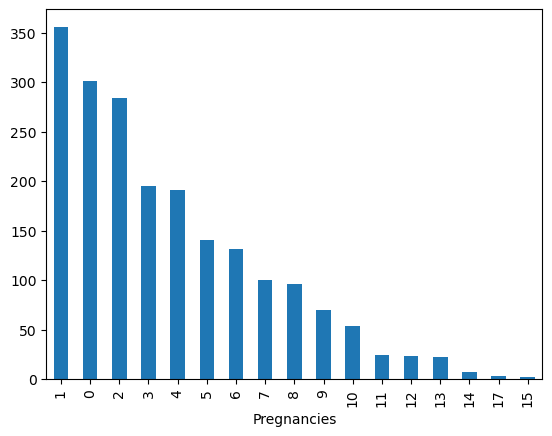

In [12]:
data["Pregnancies"].value_counts().plot(kind="bar")

In [14]:
# 📌 Handling Missing Values
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [15]:
# Remove rows with missing values
df = data.dropna()

In [16]:
# checking if there is any dublicates in your data 
df.duplicated().sum()

np.int64(1256)

In [17]:
# drop all duplicates from your data 
data.drop_duplicates(inplace=True)


In [18]:
data.duplicated().sum()

np.int64(0)

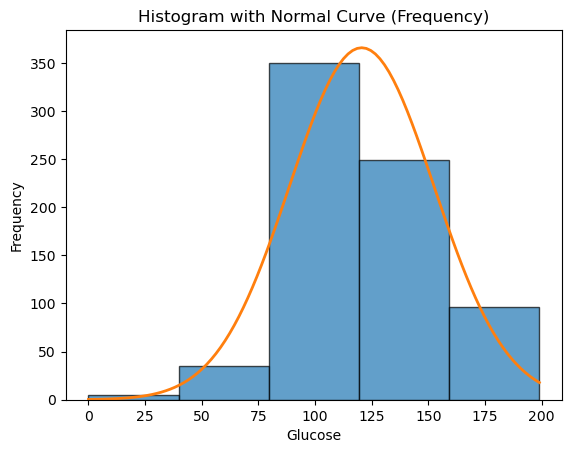

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

data = df['Glucose']

# Histogram (frequency)
counts, bins, _ = plt.hist(data, bins=5, edgecolor='black', alpha=0.7)

# Normal curve scaled to frequency
x = np.linspace(data.min(), data.max(), 100)
bin_width = bins[1] - bins[0]
y = norm.pdf(x, data.mean(), data.std()) * len(data) * bin_width

plt.plot(x, y, lw=2)

plt.title("Histogram with Normal Curve (Frequency)")
plt.xlabel("Glucose")
plt.ylabel("Frequency")
plt.show()

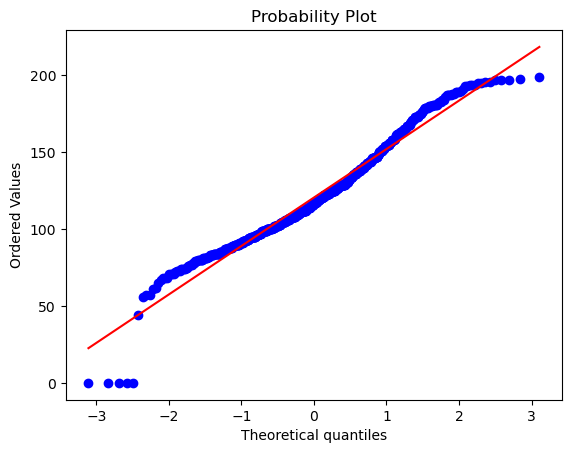

In [23]:
# visual test of data normality with Q-Q plot

import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(df['Glucose'], dist="norm", plot=plt)
plt.show()

In [24]:
# statistical test of data normality with Shapiro 
# p > 0.05 → data is approximately normal
# p < 0.05 → data is not normal
from scipy.stats import shapiro

stat, p = shapiro(df['Glucose'])

print("Statistic =", stat)
print("p-value =", p)

Statistic = 0.9708211532712584
p-value = 6.137831669508246e-11


In [26]:
# statistical test of data normality with the Kolmogorov-Smirnov Test 

from scipy.stats import kstest
import numpy as np
# p > 0.05 → data is approximately normal
# p < 0.05 → data is not normal

data = df['Glucose']

stat, p = kstest(data, 'norm',
                 args=(np.mean(data), np.std(data)))

print("Statistic =", stat)
print("p-value =", p)

Statistic = 0.06201801213060498
p-value = 0.006702094761365686


In [29]:
# statistical test of data normality with the Anderson-Darling test.
from scipy.stats import anderson
# If statistic < critical value
# → data are normal
# If statistic > critical value
# → data are not normal
# from scipy.stats import anderson

result = anderson(df['Glucose'])

print("Statistic:", result.statistic)
print("Critical values:", result.critical_values)

Statistic: 5.442143361709441
Critical values: [0.573 0.652 0.783 0.913 1.086]


In [30]:
# Example for Multiple Variables with shapiro test 

from scipy.stats import shapiro

for col in df.columns:
    stat, p = shapiro(df[col])
    print(f"{col}: p-value = {p}")

Pregnancies: p-value = 2.0939178603634037e-21
Glucose: p-value = 6.137831669508246e-11
BloodPressure: p-value = 4.774876574227846e-28
SkinThickness: p-value = 9.035231917639259e-21
Insulin: p-value = 1.2787142034737176e-32
BMI: p-value = 7.869781768236955e-15
DiabetesPedigreeFunction: p-value = 4.838510116715006e-26
Age: p-value = 3.350928051682794e-24
Outcome: p-value = 4.4803105081517135e-38


In [31]:
# 📌 Calculate the Correlation Matrix

# Pearson correlation matrix
corr_matrix = df.corr(method='pearson')
print(corr_matrix)


                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.121368       0.142190      -0.058428   
Glucose                      0.121368  1.000000       0.150184       0.060753   
BloodPressure                0.142190  0.150184       1.000000       0.219768   
SkinThickness               -0.058428  0.060753       0.219768       1.000000   
Insulin                     -0.051457  0.321739       0.099335       0.436471   
BMI                          0.032913  0.228832       0.308072       0.394901   
DiabetesPedigreeFunction    -0.023273  0.132741       0.051169       0.183987   
Age                          0.547146  0.249796       0.237671      -0.114616   
Outcome                      0.221305  0.461870       0.068852       0.073285   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies              -0.051457  0.032913                 -0.023273   
Glucose                   0.321739  0.228

In [41]:
# You can also use other methods:
# This method is used when the data normality is violated 
# Spearman correlation
spearman_corr = df.corr(method='spearman')
print(spearman_corr)

                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.121434       0.172532      -0.061103   
Glucose                      0.121434  1.000000       0.233210       0.062269   
BloodPressure                0.172532  0.233210       1.000000       0.141503   
SkinThickness               -0.061103  0.062269       0.141503       1.000000   
Insulin                     -0.105462  0.211002       0.004189       0.530718   
BMI                          0.008331  0.234409       0.304040       0.451735   
DiabetesPedigreeFunction    -0.035226  0.079301       0.034293       0.178150   
Age                          0.608611  0.270924       0.348175      -0.061039   
Outcome                      0.195878  0.472452       0.150133       0.088367   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies              -0.105462  0.008331                 -0.035226   
Glucose                   0.211002  0.234

In [42]:
# Kendall correlation
kendall_corr = df.corr(method='kendall')
print(kendall_corr)

                          Pregnancies   Glucose  BloodPressure  SkinThickness  \
Pregnancies                  1.000000  0.085218       0.126489      -0.046359   
Glucose                      0.085218  1.000000       0.158867       0.040551   
BloodPressure                0.126489  0.158867       1.000000       0.105191   
SkinThickness               -0.046359  0.040551       0.105191       1.000000   
Insulin                     -0.080109  0.162174       0.004222       0.410902   
BMI                          0.009864  0.158707       0.212444       0.336778   
DiabetesPedigreeFunction    -0.024328  0.053772       0.022374       0.124528   
Age                          0.460518  0.186751       0.245242      -0.040595   
Outcome                      0.168095  0.387848       0.125253       0.075067   

                           Insulin       BMI  DiabetesPedigreeFunction  \
Pregnancies              -0.080109  0.009864                 -0.024328   
Glucose                   0.162174  0.158

In [36]:
# 📌 Calculate Correlation Between Two Specific Variables

# Correlation between Plant Height and Yield
r = df['Glucose'].corr(df['BMI'])
print("Correlation coefficient:", r)

Correlation coefficient: 0.22883204717039488


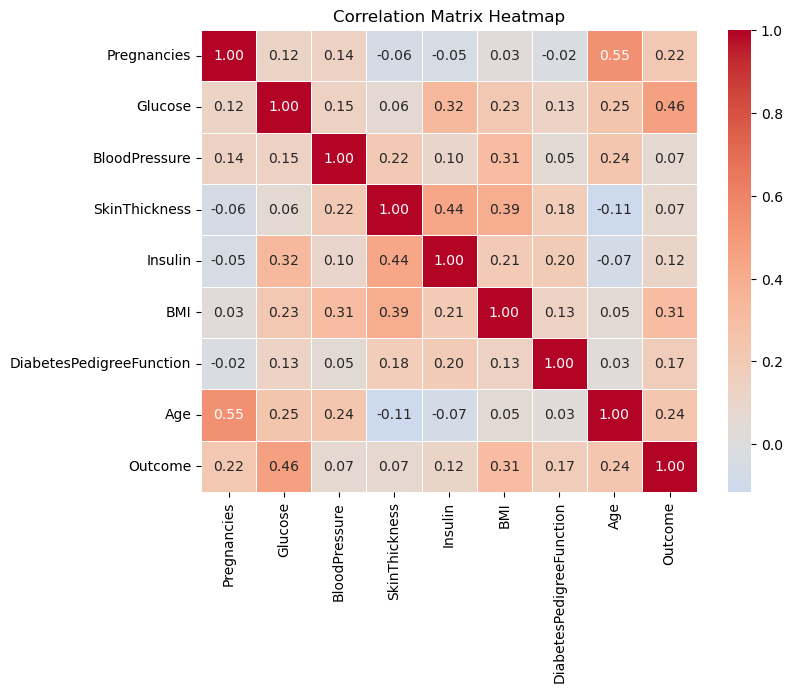

In [37]:
# 📌 Visualize the Correlation Matrix (Heatmap)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    center=0,
    fmt='.2f',
    linewidths=0.5
)
plt.title('Correlation Matrix Heatmap')
plt.show()


In [38]:
#📌 Statistical Significance (p-value)

from scipy.stats import pearsonr, spearmanr

# Pearson correlation with p-value
r, p = pearsonr(df['Glucose'], df['BMI'])

print(f"Pearson correlation coefficient: {r:.4f}")
print(f"P-value: {p:.6f}")

Pearson correlation coefficient: 0.2288
P-value: 0.000000


In [39]:
# For Spearman correlation:

rho, p = spearmanr(df['Glucose'], df['BMI'])
print(f"Spearman correlation coefficient: {rho:.4f}")
print(f"P-value: {p:.6f}")

Spearman correlation coefficient: 0.2344
P-value: 0.000000


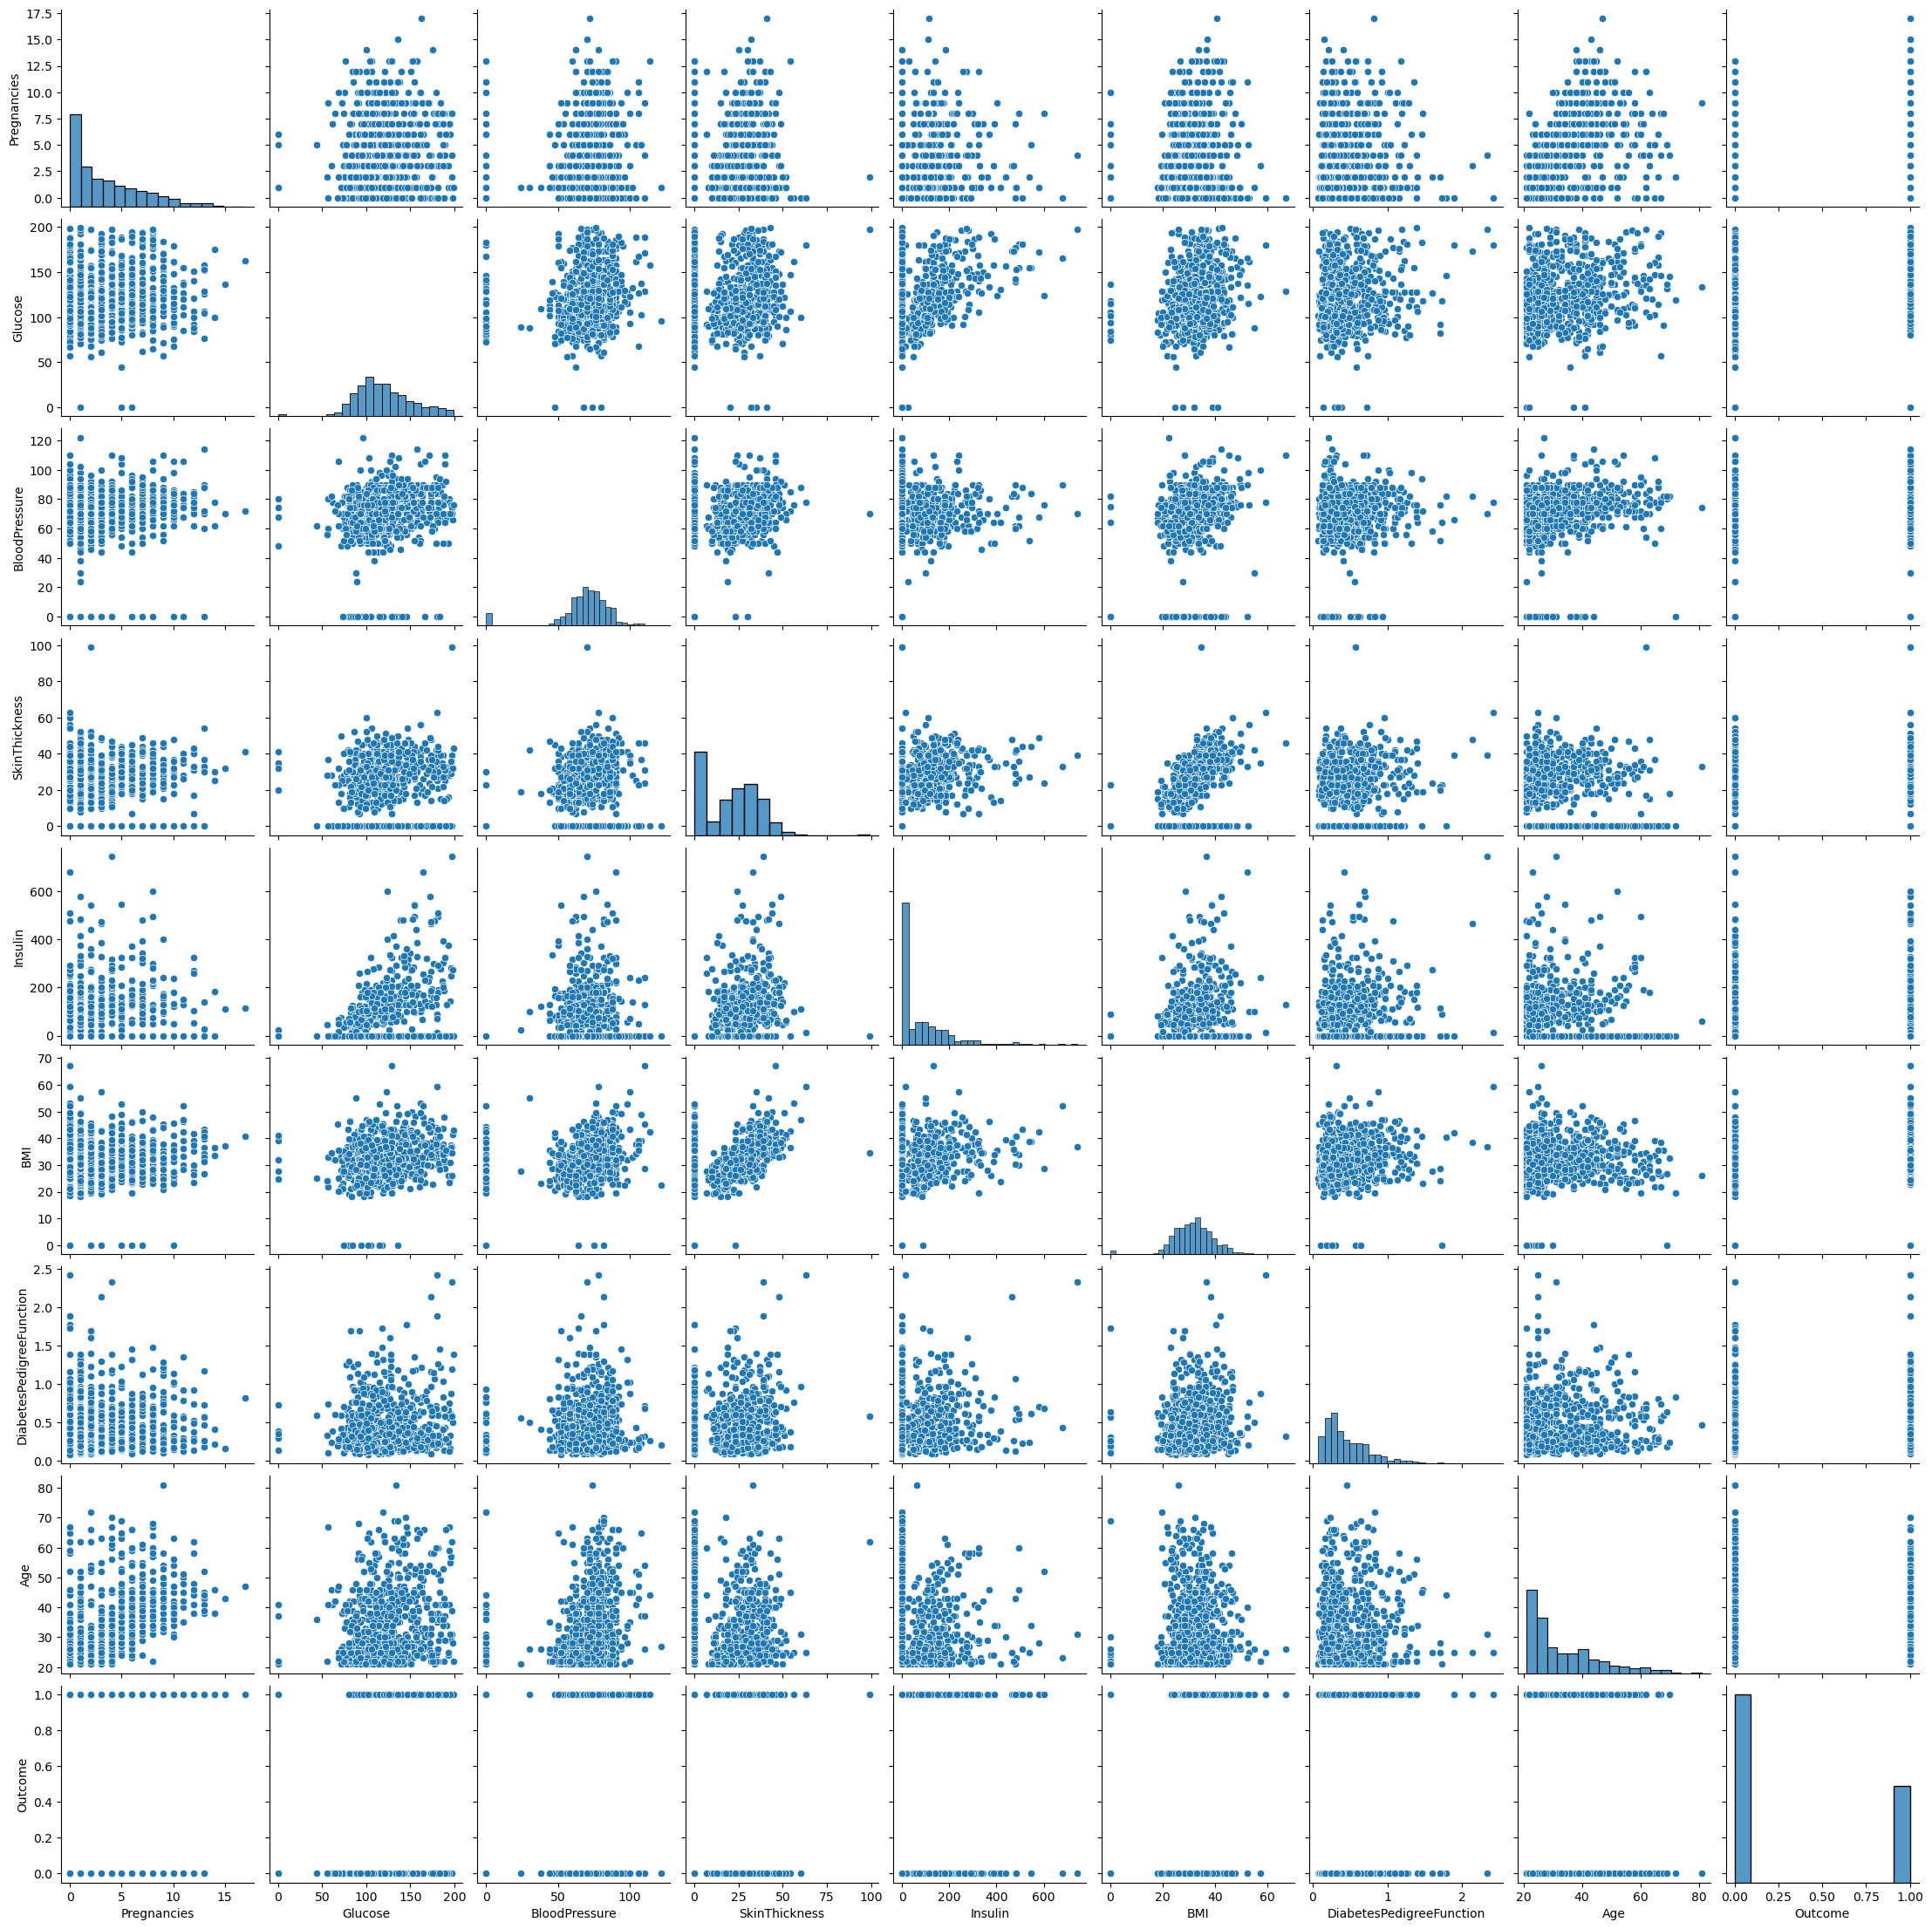

In [40]:

# 📌 Pairwise Scatter Plots

sns.pairplot(df)
plt.show()
# This helps identify linear and non-linear relationships among all variables.

# 📌 Interpretation Guide

# Correlation (absolute value) Interpretation

# 0.00–0.19 Very weak
# 0.20–0.39 Weak
# 0.40–0.59 Moderate
# 0.60–0.79 Strong
# 0.80–1.00 Very strong

# Sign:

# Positive (+): both variables increase together.
# egative (−): one increases while the other decreases.